This is a compilation of examples of uses of RSRS

In [ ]:
from rsrs_config import RSRSBenchmarkConfig
import numpy as np
print(RSRSBenchmarkConfig.__init__.__doc__)

: 

In [ ]:
## Generate the test case either to run the test or retrieve results
## recommendations: if operator_type = 5, and if ref_level = 8, pick depth = 4 (this is a problem of around 500k dofs)
## if ref_level = 9, pick depth = 5 (this is a problem of around 2MM dofs)
#config = RSRSBenchmarkConfig(operator_type=5, dim_arg_type=3, ref_level=5, depth=3, min_level = 1, factors_cn = True, op_stabilisation=0.0001)
#config = RSRSBenchmarkConfig(operator_type=14, geometry=10, dim_arg_type=1, min_level=1, h=0.08, kappa = 1, factors_cn = False, dense_errors =False, max_tree_depth=6, rrqr=0, f=1.0)
#config = RSRSBenchmarkConfig(operator_type=15, id_tols = [40], dim_arg_type=1, geometry=6, min_level=1, h=0.2, kappa=1, factors_cn = False, dense_errors =False, max_tree_depth=6, rrqr=0, f=1.0, n_sources=1)
#config = RSRSBenchmarkConfig(operator_type=18, dim_arg_type=1, geometry=0, min_level=1, h=0.1, depth = 2, kappa = 0.1, factors_cn = False, dense_errors =False, max_tree_depth=16, rrqr=0, f=1.0, n_sources=1, solve = False, symmetric=False, save_samples=False)
config = RSRSBenchmarkConfig(operator_type=20, dim_arg_type=0, geometry=0, min_level=1, h=0.1, kappa = 2.0, factors_cn = False, dense_errors =True, max_tree_depth=2, rrqr=0, f=1.0, n_sources=1, num_threads=8, solve = True, save_samples = False, symmetric=False)

In [11]:
## Generate the shell script (disable it unless you want to run the test)
config.generate_bash_script("run_test.sh")

In [7]:
## Running test in Rust

#!./run_test.sh

In [4]:
config.get_far_field(tol=100, n_grid_points = 400, plane=0, lims=[-10, 10, -10, 10], c = -1.0)

IndexError: list index out of range

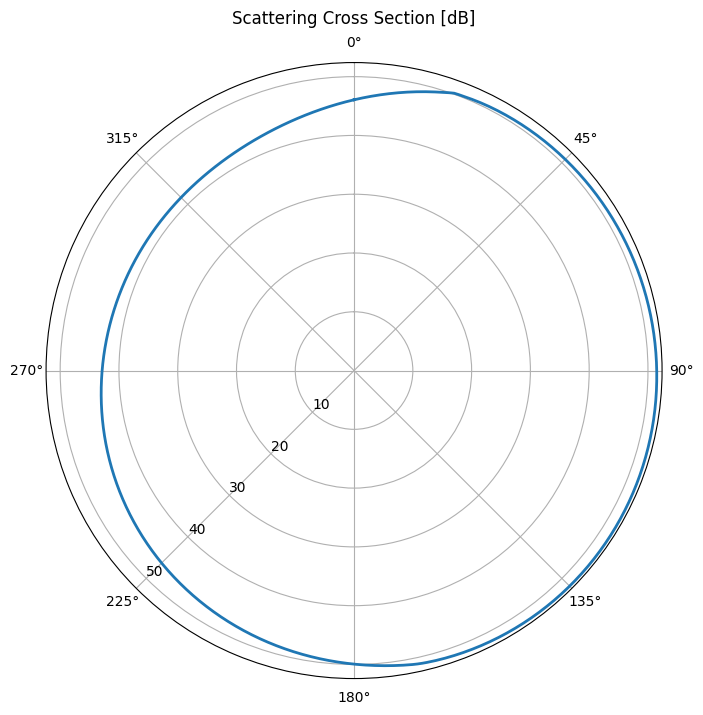

In [ ]:
config.get_rcs(tol=60, number_of_angles=400, polar=True, plane = 0)

In [5]:
print("This problem has " + str(config.get_degrees_of_freedom()) + " degrees of freedom")

This problem has 8192 degrees of freedom


In [6]:
print(config.plot_errors_vs_tolerance.__doc__)


        Plot a specified error metric vs tolerance.

        Parameters
        ----------
        metric_index : int
            The index of the error metric to plot on the y-axis. Must be one of:
            1 - 'norm_2_error'
            2 - 'norm_2_error_inv'
            3 - 'app_condition_number'
            4 - 'tot_num_samples'
            5 - 'residual_size'
        logx : bool
            If True, use logarithmic scale for the x-axis (tolerance).
        logy : bool
            If True, use logarithmic scale for the y-axis (metric).

        Raises
        ------
        ValueError
            If `metric_index` is not in the range 1 to 5.
        


[1e-08, 1e-06, 0.0001, 0.001, 0.01] [1.3410436799368081e-14, 2.731505449990476e-07, 2.0017319584429343e-05, 0.00014167377745921065, 0.0014059543593342616]


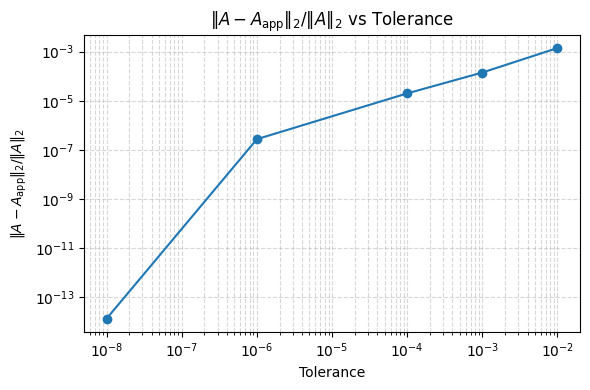

In [26]:
config.plot_errors_vs_tolerance(1)

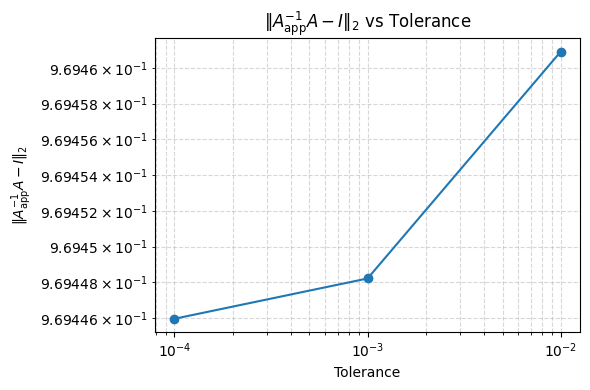

In [8]:
config.plot_errors_vs_tolerance(2)

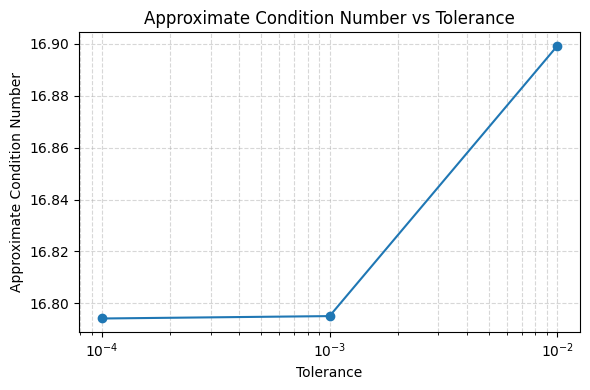

In [9]:
config.plot_errors_vs_tolerance(3, logy=False)

In [10]:
config.plot_errors_vs_tolerance(4, False)

[[0.0001, 0.001, 0.01], [995, 667, 464]]

In [11]:
config.plot_errors_vs_tolerance(5, False)

[[0.0001, 0.001, 0.01], [7594, 7847, 7958]]

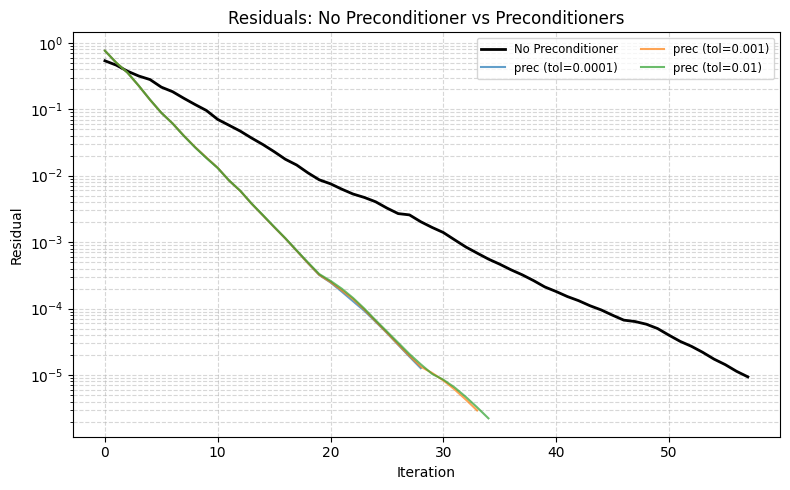

In [12]:
config.plot_gmres_residuals()

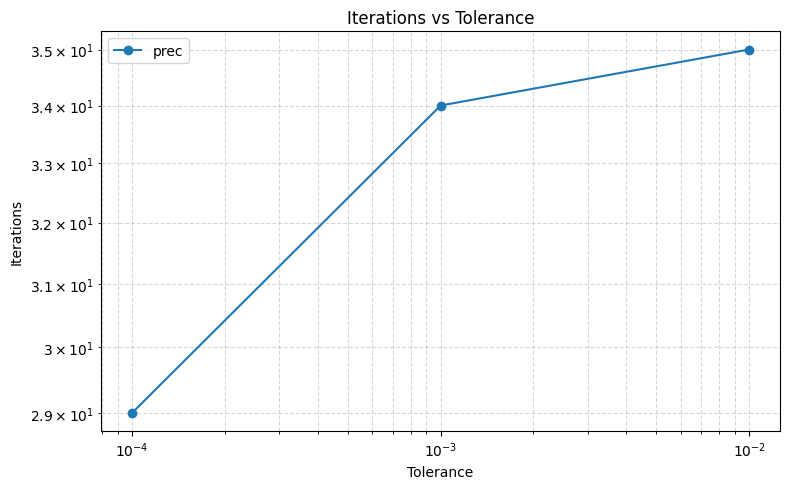

In [13]:
config.plot_residual_convergence()

In [14]:
print(config.plot_total_elapsed_time_vs_tolerance.__doc__)


        Plot total elapsed time without sampling vs tolerance (in seconds).

        Parameters
        ----------
        logx : bool, optional
            If True, use log scale on the x-axis (tolerance).
        logy : bool, optional
            If True, use log scale on the y-axis (time).
        


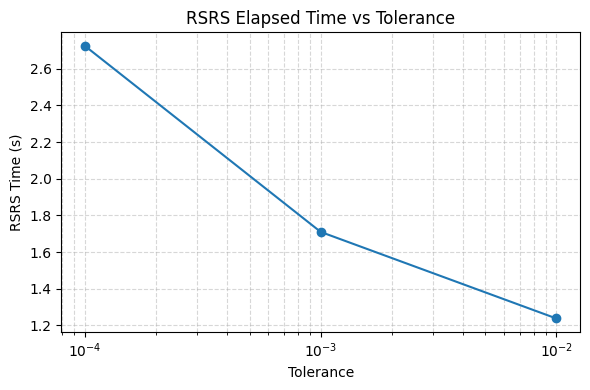

In [15]:
config.plot_total_elapsed_time_vs_tolerance(logy=False)

In [16]:
print(config.plot_time_breakdown_piecharts.__doc__)


        Plot a pie chart of time breakdown for each tolerance.

        Parameters
        ----------
        max_charts : int or None
            Maximum number of pie charts to display. If None, shows all.
        


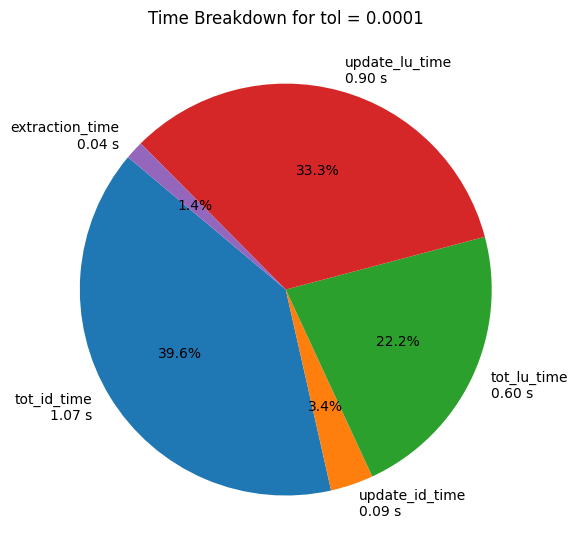

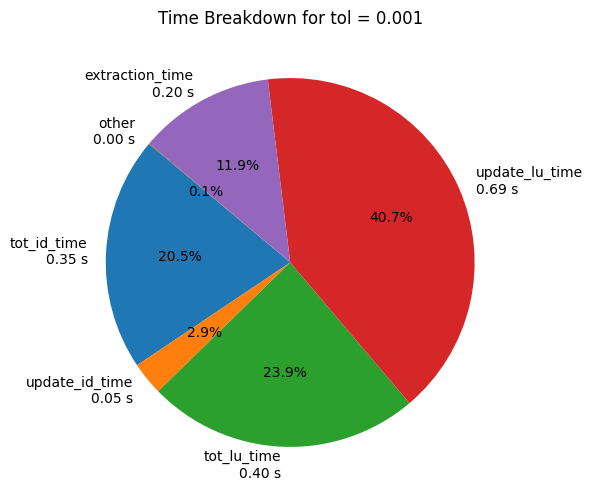

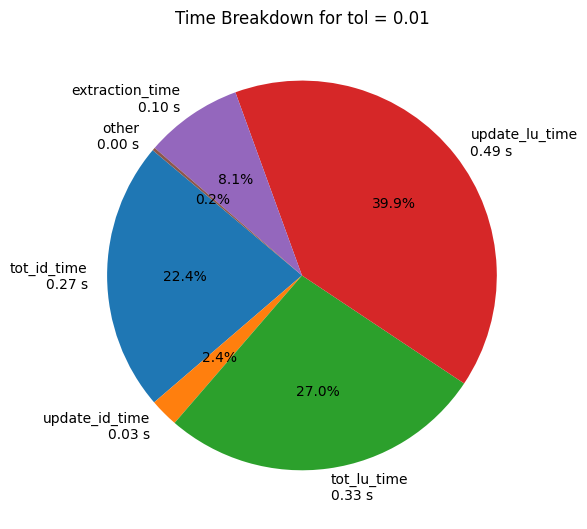

In [17]:
config.plot_time_breakdown_piecharts()

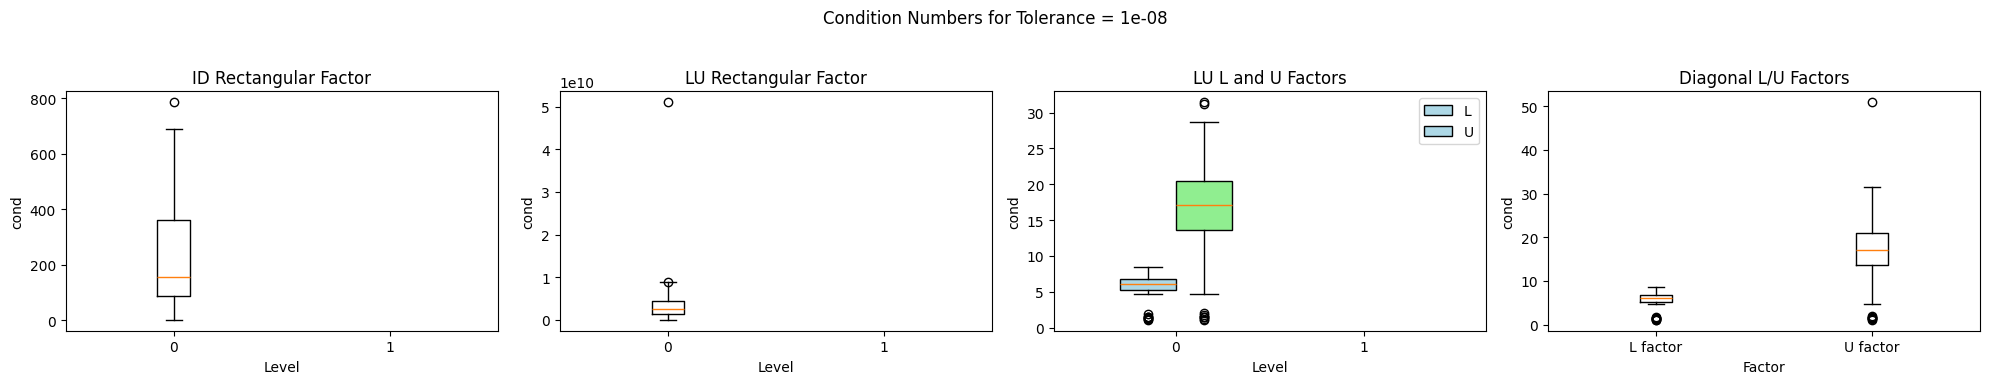

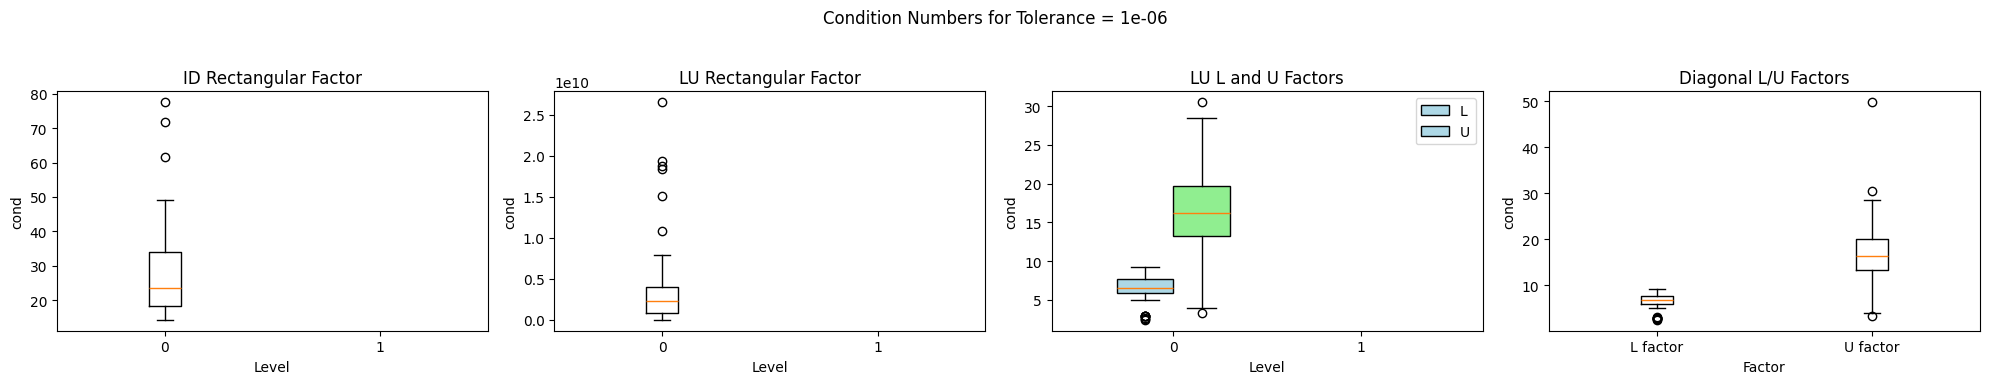

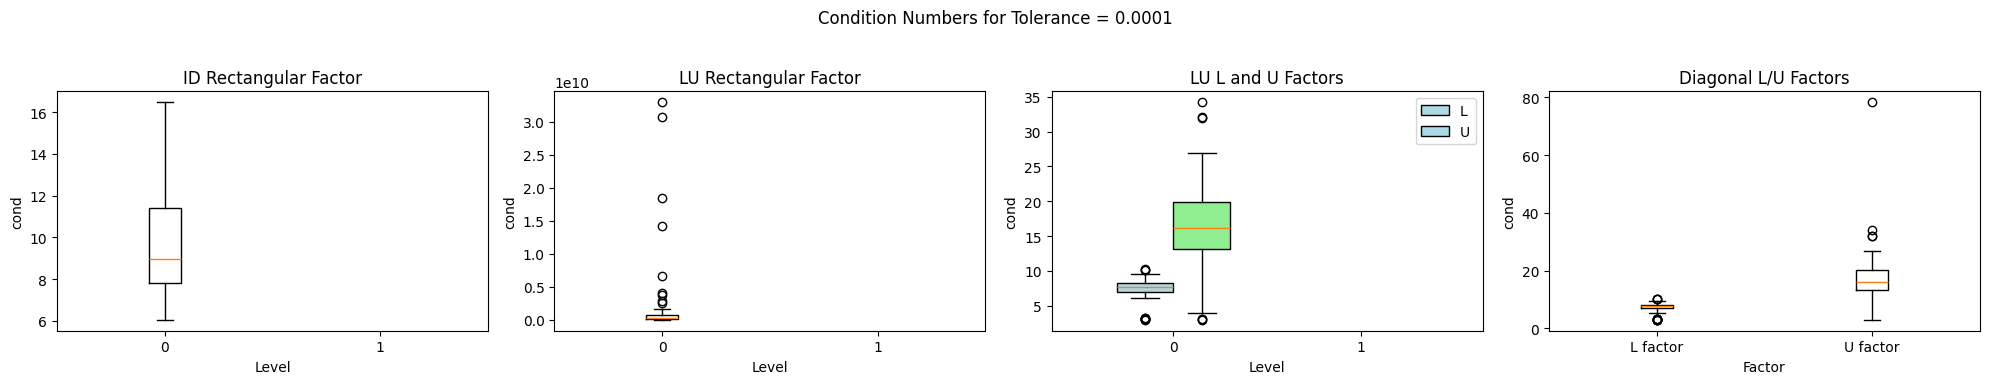

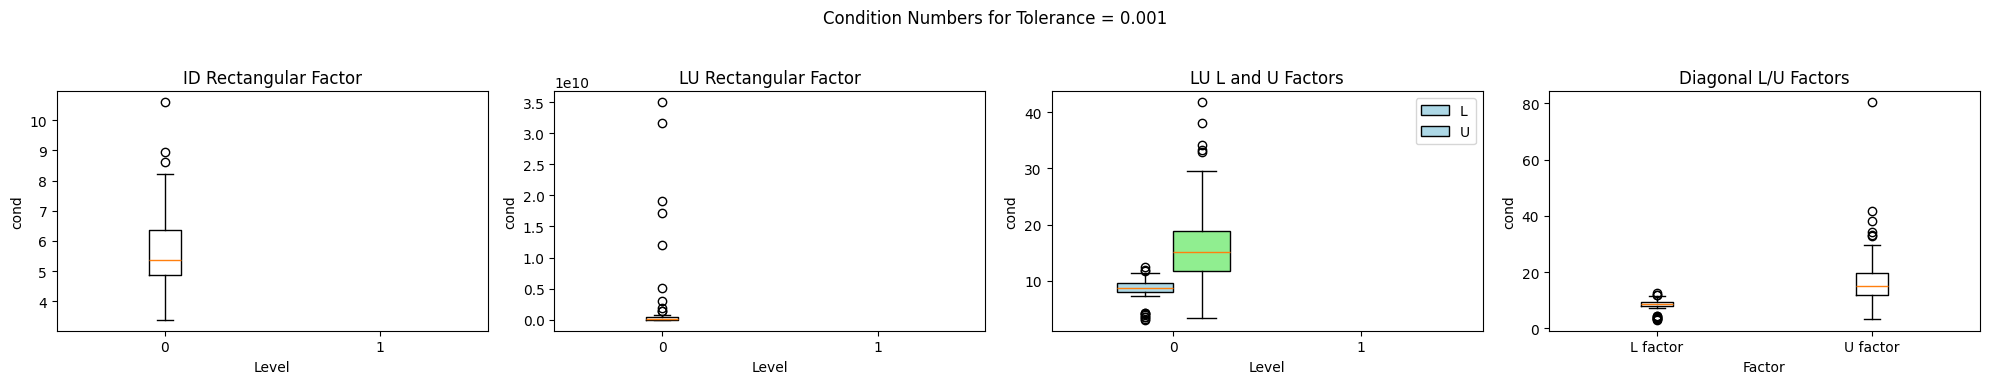

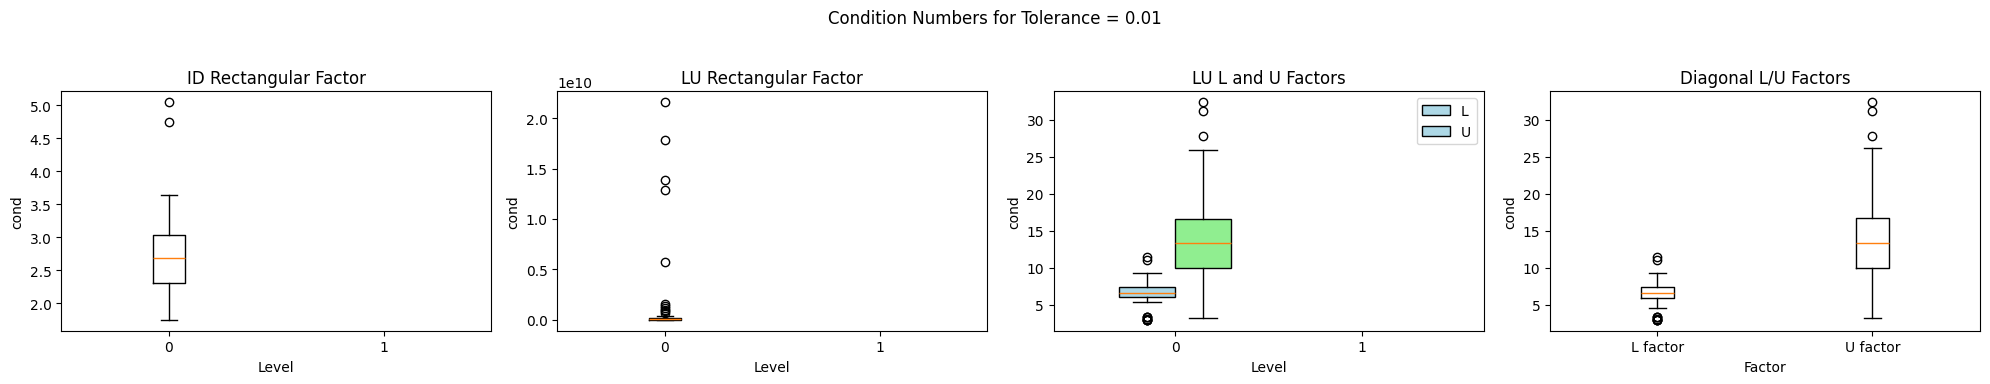

In [8]:
config.plot_factor_metrics(metric = "cond")

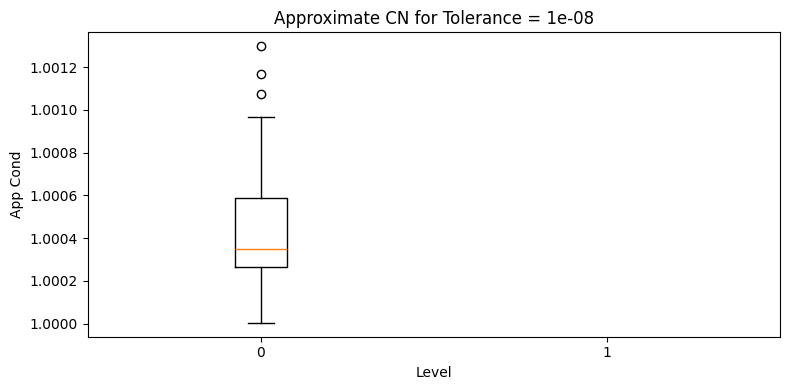

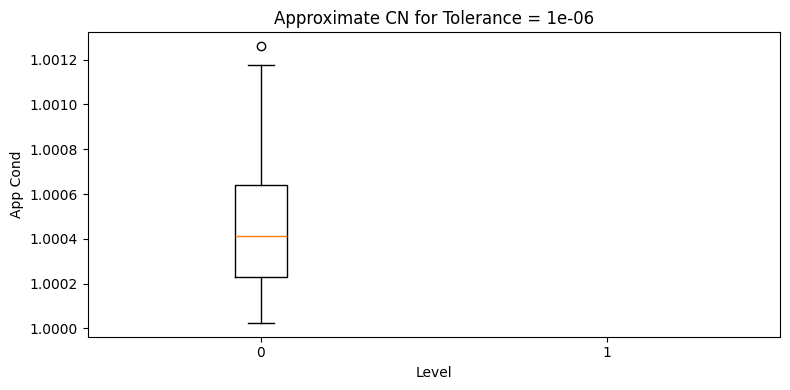

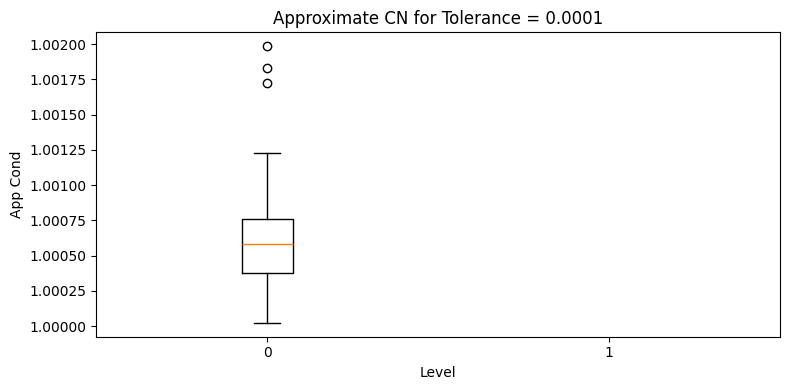

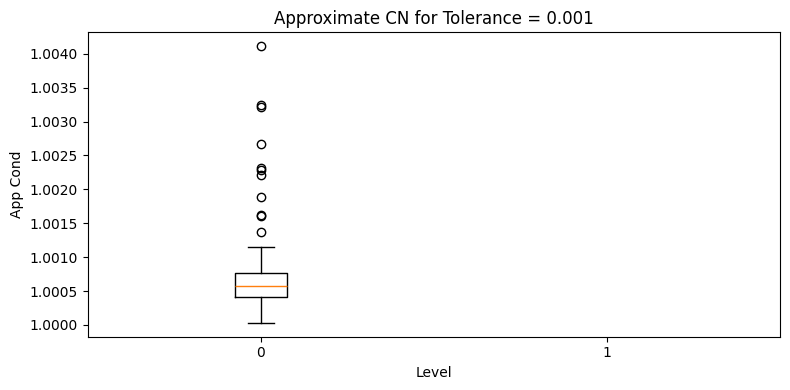

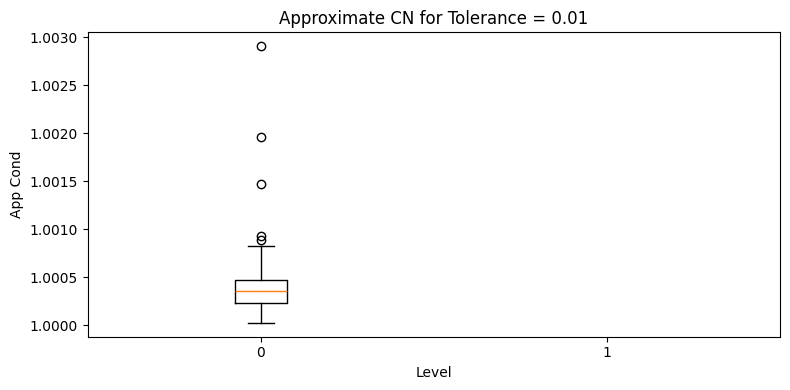

In [7]:
config.plot_lu_factors_app_cond()

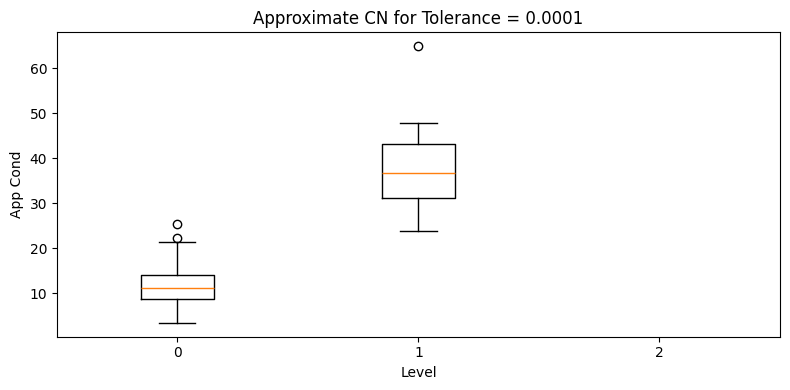

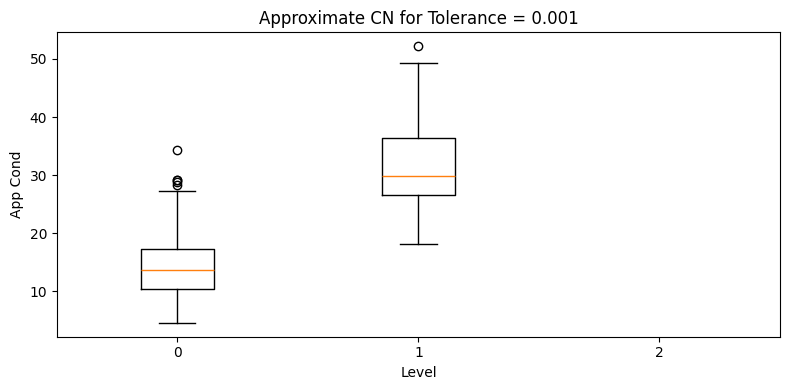

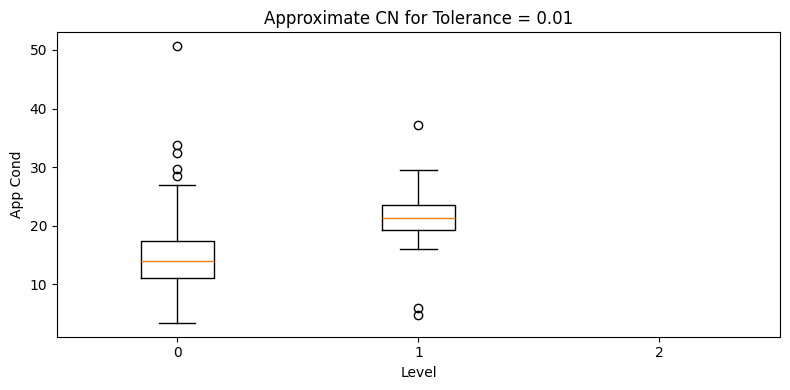

In [32]:
config.plot_id_factors_app_cond()

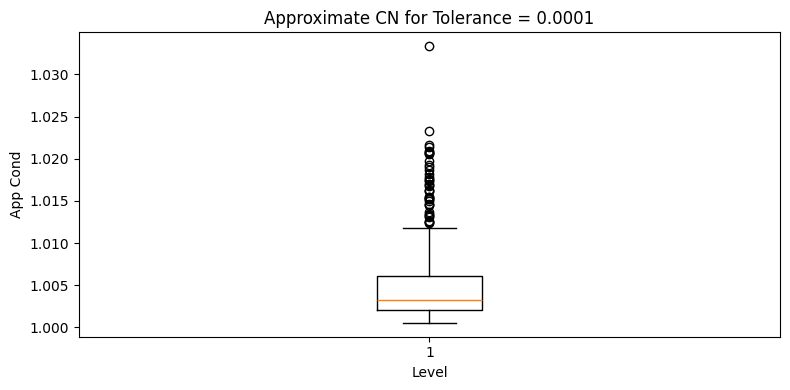

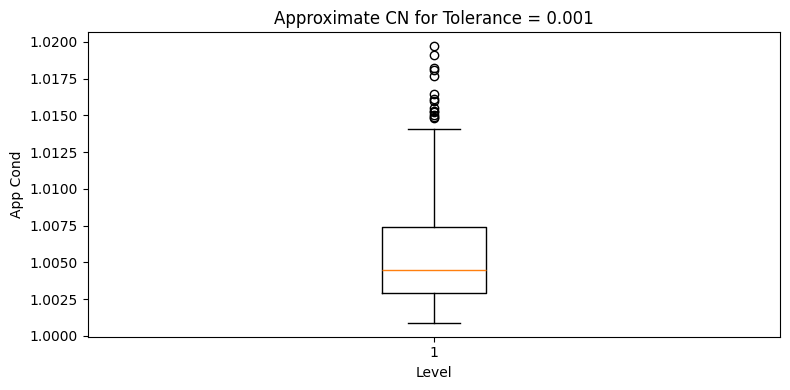

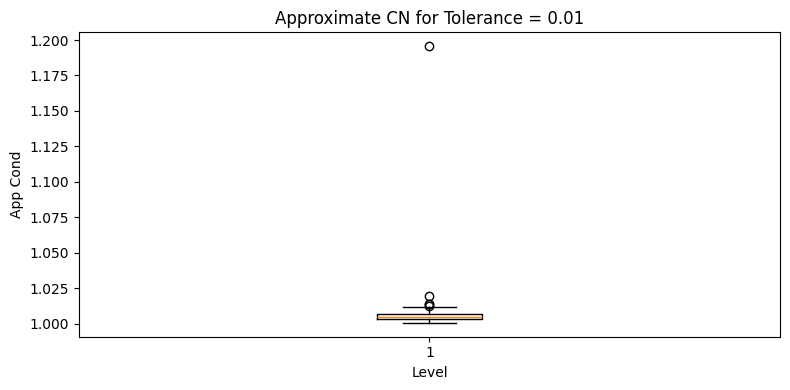

In [33]:
config.plot_d_factor_app_cond()

In [12]:
import bempp_cl.api
grid = bempp_cl.api.shapes.sphere(h=0.5)
domain = bempp_cl.api.function_space(grid, "DP", 0)
dual_to_range = domain
range = domain
mat = bempp_cl.api.operators.boundary.helmholtz.single_layer(
                domain, range, dual_to_range, np.pi).weak_form()

In [14]:
mat.transpose()

<226x226 DenseDiscreteBoundaryOperator with dtype=complex128>

In [19]:
def is_hermitian_exact(A):
    return np.array_equal(A, A.T)

def is_hermitian(A, tol=1e-12):
    return np.allclose(A, A.T.conj(), atol=tol)


is_hermitian(mat.to_dense(), 1e-2)

True